# Pseudo Cryo-ET Data Generation from Membrane Mesh
This notebook demonstrates how to:
1. Load Mem3DG-generated membrane mesh data (`data/raw/biconcave.nc`).
2. Generate pseudo cryo-ET data.
3. Save and visualize the output.


In [1]:
import sys
from pathlib import Path

# Get the absolute path of the project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add "src/" to sys.path
sys.path.append(str(project_root / "src"))

Pseudo cryo-ET data saved to: ../data/synthetic/biconcave_noisy_015.mrc


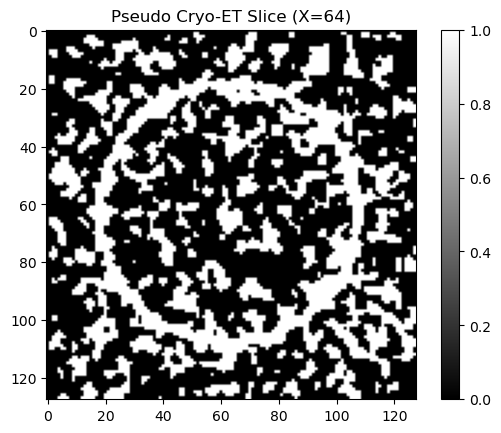

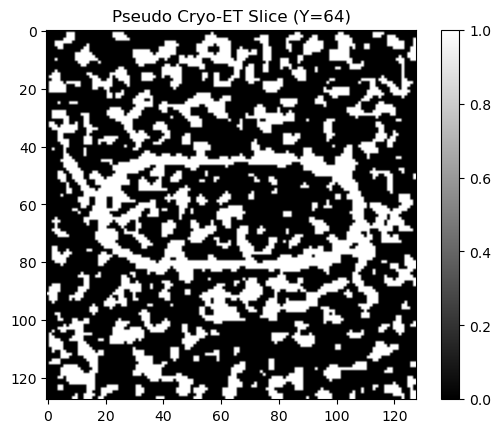

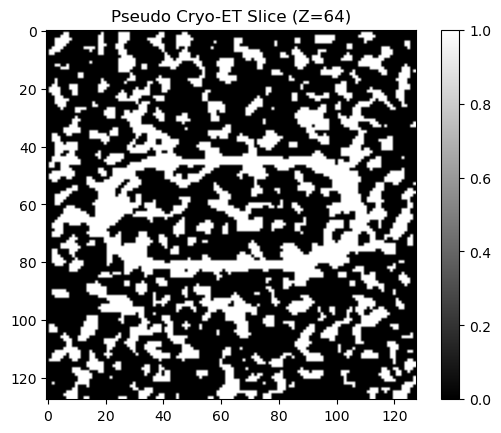

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from data_generation.mesh_to_cryoet import generate_pseudo_cryoet, plot_single_slice

# missing_ratio=0.0
flip_ratio=0.15

# Path to Mem3DG-generated trajectory file
input_file = "../data/raw/biconcave.nc"

# Path to save the generated pseudo cryo-ET data
# output_file = "../data/synthetic/biconcave.mrc"
# output_file = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
output_file = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"

# Generate pseudo cryo-ET volume
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=1.0)
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=1.0, missing_ratio=missing_ratio)
pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=1.0, flip_ratio=flip_ratio)

thre = 0.8
# Visualize the middle slice in different directions
plot_single_slice(pseudo_cryoET, axis='x', thre=thre)  # X-direction
plot_single_slice(pseudo_cryoET, axis='y', thre=thre)  # Y-direction
plot_single_slice(pseudo_cryoET, axis='z', thre=thre)  # Z-direction

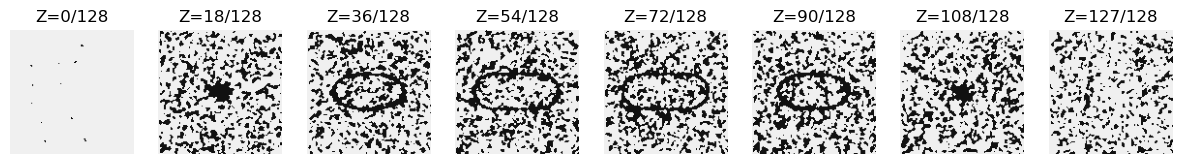

In [5]:
from data_generation.mesh_to_cryoet import plot_multiple_slices
import mrcfile

# missing_ratio=0.9
flip_ratio=0.15

# output_file = "../data/synthetic/biconcave.mrc"
# output_file = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
output_file = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"

# Load pseudo cryo-ET data
with mrcfile.open(output_file, permissive=True) as mrc:
    volume = mrc.data

# Correct function call
plot_multiple_slices(volume, axis='z', num_slices=8, thre=0.8)


In [3]:
# measure length

import numpy as np
from netCDF4 import Dataset

# Path to Mem3DG-generated trajectory file
input_file = "../data/raw/biconcave.nc"
data = Dataset(input_file, 'r')


# Access the 'Trajectory' group
coords = data.groups['Trajectory'].variables['coordinates'][-1]
coords = coords.reshape(-1, 3)

min_bound = np.min(coords, axis=0)
max_bound = np.max(coords, axis=0)
extent = max_bound - min_bound

print("x-length = ", extent[0])
print("y-length = ", extent[1])
print("z-length = ", extent[2])


x-length =  2.37126752123156
y-length =  2.37008613382773
z-length =  0.9744919523084066
